In [1]:
import pandas as pd
from pathlib import Path
from neural_priors.utils.data import Subject, get_all_subject_ids, get_all_behavioral_data
from neural_priors.encoding_model.decode import get_decoding_paradigm
import numpy as np
from tqdm.notebook import tqdm
from tqdm.contrib.itertools import product
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

bids_folder = Path('/data/ds-neuralpriors')

model_label = 31
spherical_noise = False

def get_pdf(subject, smoothed=False, model_label=4, fit_responses=False, n_voxels=100, spherical_noise=False):
    # Load subject
    sub = Subject(subject, bids_folder=bids_folder)

    # Create target folder
    key = f'model{model_label}'

    if smoothed:
        key += '.smoothed'

    if spherical_noise:
        key += '.spherical_noise'

    if fit_responses:
        key += '.fit_responses'

    target_dir = bids_folder / 'derivatives' / 'decoding2' / key / f'sub-{subject}' / 'func'

    # Index columns: session, run, trial_nr, x, range  (5 levels)
    # Column header rows: n, range_condition  (2 levels)
    pdf = pd.read_csv(target_dir / f'sub-{subject}_mask-NPCr_nvoxels-{n_voxels}_pars.tsv',
                      sep='\t', index_col=[0, 1, 2, 3, 4], header=[0, 1])

    pdf.columns.names = ['n', 'range']

    # Make first level of columns float32
    new_columns = pd.MultiIndex.from_arrays(
        [pdf.columns.get_level_values(0).astype(np.float32),
         pdf.columns.get_level_values(1)],
        names=pdf.columns.names)
    pdf.columns = new_columns

    # Sort into original presentation order
    pdf = pdf.sort_index(level=['session', 'run', 'trial_nr'])

    return pdf

def summarize_pdf(pdf, censored=False):
    pdf0 = pdf.xs('0.0', level=1, axis=1)

    pdf0 = pdf0.loc[:, :25.0]
    
    pdf0 /= np.trapz(pdf0, pdf0.columns.astype(np.float32), axis=1)[:, np.newaxis]
    E0 = np.trapz(pdf0 * pdf0.columns.values.astype(float)[np.newaxis, :], pdf0.columns.astype(np.float32), axis=1)

    sd0 = np.trapz(np.abs(E0[:, np.newaxis] - pdf0.columns.values.astype(float)[np.newaxis, :]) * pdf0, pdf0.columns.astype(np.float32), axis=1)




    pdf1 = pdf.xs('1.0', level=1, axis=1)

    if censored:
        # For censored trials, we only have the truncated pdf, so we need to renormalize it before computing E and sd
        pdf1 = pdf1.loc[:, :25.0]

    pdf1 /= np.trapz(pdf1, pdf1.columns.astype(np.float32), axis=1)[:, np.newaxis]

    E1 = np.trapz(pdf1 * pdf1.columns.values.astype(float)[np.newaxis, :], pdf1.columns.astype(np.float32), axis=1)
    sd1 = np.trapz(np.abs(E1[:, np.newaxis] - pdf1.columns.values.astype(float)[np.newaxis, :]) * pdf1, pdf1.columns.astype(np.float32), axis=1)

    E = np.where(pdf.index.get_level_values('range') == 0.0, E0, E1)
    sd = np.where(pdf.index.get_level_values('range') == 0.0, sd0, sd1)

    pars = pd.DataFrame(index=pdf.index, columns=['E', 'sd'])
    pars['E'] = E
    pars['sd'] = sd

    pars.reset_index(['x', 'range'], inplace=True)

    pars['error'] = pars['E'] - pars['x']
    pars['abs(error)'] = np.abs(pars['error'])

    return pars

In [2]:
subjects = get_all_subject_ids()

fit_responses = False
model_label = 31

pdfs = []
keys = []
pars_list = []

for subject, spherical_noise, n_voxels, censored in product(subjects, [False, True], [0, 100], [False, True]):
    try:
        pdf = get_pdf(subject, smoothed=True, model_label=model_label, fit_responses=fit_responses,
                      n_voxels=n_voxels, spherical_noise=spherical_noise)
        pars_ = summarize_pdf(pdf, censored=censored)
        pdfs.append(pdf)
        keys.append((subject, spherical_noise, n_voxels, censored))
        pars_list.append(pars_)
    except FileNotFoundError as e:
        print(f'File not found: sub-{subject}, spherical_noise={spherical_noise}, n_voxels={n_voxels}: {e}')
        continue
    # except Exception as e:
    #     print(f'Error: sub-{subject}, spherical_noise={spherical_noise}, n_voxels={n_voxels}: {e}')
    #     continue

pdf = pd.concat(pdfs, keys=keys, names=['subject', 'spherical_noise', 'n_voxels', 'censored'])
pars = pd.concat(pars_list, keys=keys, names=['subject', 'spherical_noise', 'n_voxels', 'censored'])

pars['range'] = pars['range'].map({0.0: 'narrow', 1.0: 'wide'})


# pars = pars[~(pars

# Drop all rows where censored is True and x > 25 (censored is an index level not a column)
pars = pars[~((pars.index.get_level_values('censored') == True) & (pars['x'] > 25))]

  0%|          | 0/312 [00:00<?, ?it/s]

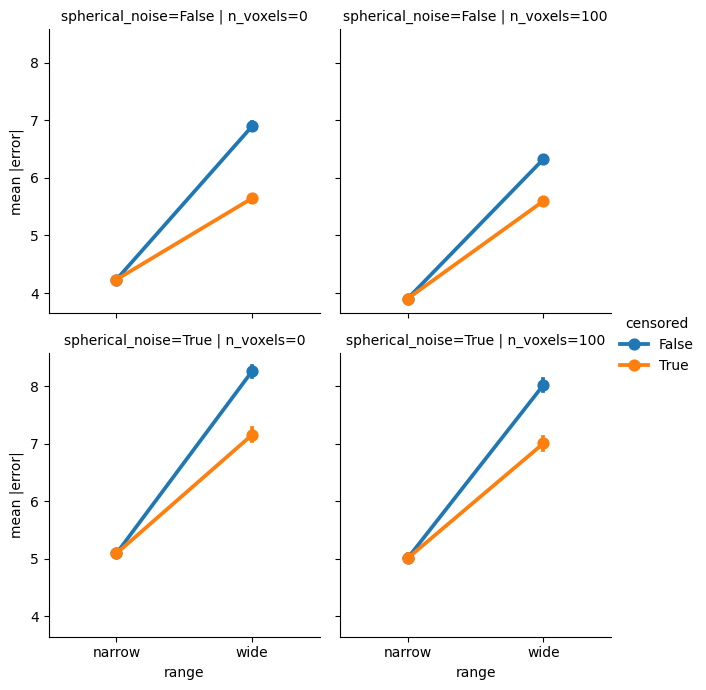

In [3]:
# Mean absolute error, split by censored (x < 26) and uncensored (all trials)
mean_abs_error = pd.concat([
    pars.groupby(['subject', 'spherical_noise', 'n_voxels', 'range'])['abs(error)']
        .mean().reset_index().assign(censored=False),
    pars[pars['x'] < 26].groupby(['subject', 'spherical_noise', 'n_voxels', 'range'])['abs(error)']
        .mean().reset_index().assign(censored=True),
], ignore_index=True)

g = sns.catplot(
    data=mean_abs_error,
    x='range', y='abs(error)', hue='censored',
    col='n_voxels', row='spherical_noise',
    kind='point', errorbar='se',
    height=3.5, aspect=0.9
)
g.set_titles('spherical_noise={row_name} | n_voxels={col_name}')
g.set_axis_labels('range', 'mean |error|')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_96086/223377664.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return (df.groupby(['subject', 'spherical_noise', 'n_voxels', 'range', 'run', 'session'])
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_96086/223377664.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return (df.groupby(['subject', 'spherical_noise', 'n_voxels', 'range', 'run'

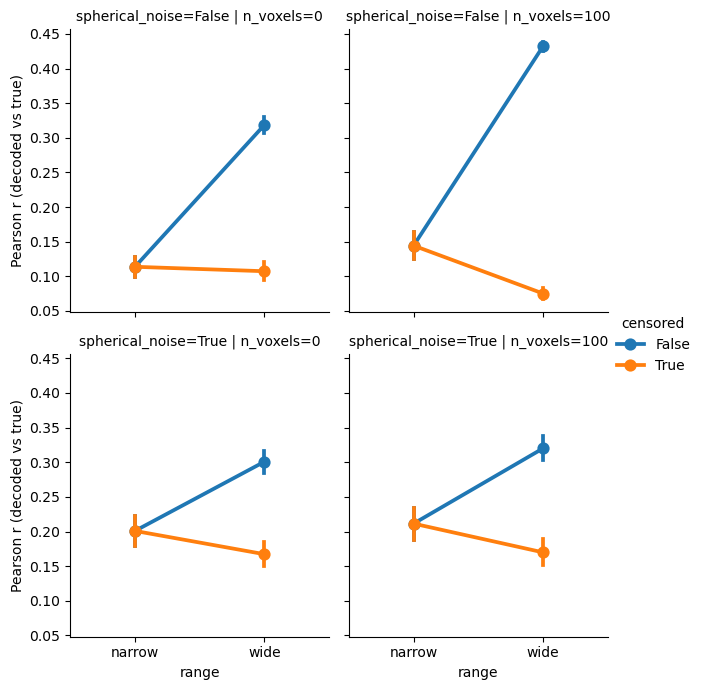

In [4]:
# Pearson r (E vs x), split by censored and uncensored
def compute_r(df):
    return (df.groupby(['subject', 'spherical_noise', 'n_voxels', 'range', 'run', 'session'])
              .apply(lambda d: pg.corr(d['E'], d['x'], method='pearson')['r'].values[0])
              .rename('r')
              .reset_index()
              .groupby(['subject', 'spherical_noise', 'n_voxels', 'range'])['r']
              .mean()
              .reset_index())

r_all = pd.concat([
    compute_r(pars).assign(censored=False),
    compute_r(pars[pars['x'] < 26]).assign(censored=True),
], ignore_index=True)

g = sns.catplot(
    data=r_all,
    x='range', y='r', hue='censored',
    col='n_voxels', row='spherical_noise',
    kind='point', errorbar='se',
    height=3.5, aspect=0.9
)
g.set_axis_labels('range', 'Pearson r (decoded vs true)')
g.set_titles('spherical_noise={row_name} | n_voxels={col_name}')

In [5]:
# Summary table: mean abs error and r averaged over subjects and range
summary = mean_abs_error.groupby(['spherical_noise', 'n_voxels', 'censored', 'range'])['abs(error)'].agg(['mean', 'sem'])
summary.columns = ['mean_abs_error', 'sem_abs_error']
r_summary = r_all.groupby(['spherical_noise', 'n_voxels', 'censored', 'range'])['r'].agg(['mean', 'sem'])
r_summary.columns = ['mean_r', 'sem_r']
pd.concat([summary, r_summary], axis=1).round(3)

mean_abs_error  sem_abs_error  \
spherical_noise n_voxels censored range                                   
False           0        False    narrow           4.235          0.032   
                                  wide             6.899          0.065   
                         True     narrow           4.235          0.032   
                                  wide             5.647          0.056   
                100      False    narrow           3.903          0.034   
                                  wide             6.326          0.041   
                         True     narrow           3.903          0.034   
                                  wide             5.598          0.038   
True            0        False    narrow           5.093          0.057   
                                  wide             8.261          0.098   
                         True     narrow           5.093          0.057   
                                  wide             7.155          0.117   
                100      False    narrow           5.010          0.068   
                                  wide             8.019          0.102   
                         True     narrow           5.010          0.068   
                                  wide             7.004          0.111   

                                          mean_r  sem_r  
spherical_noise n_voxels censored range                  
False           0        False    narrow   0.114  0.015  
                                  wide     0.319  0.012  
                         True     narrow   0.114  0.015  
                                  wide     0.107  0.013  
                100      False    narrow   0.144  0.019  
                                  wide     0.432  0.006  
                         True     narrow   0.144  0.019  
                                  wide     0.075  0.009  
True            0        False    narrow   0.201  0.022  
                                  wide     0.301  0.016  
                         True     narrow   0.201  0.022  
                                  wide     0.167  0.018  
                100      False    narrow   0.211  0.023  
                                  wide     0.320  0.017  
                         True     narrow   0.211  0.023  
                                  wide     0.170  0.019

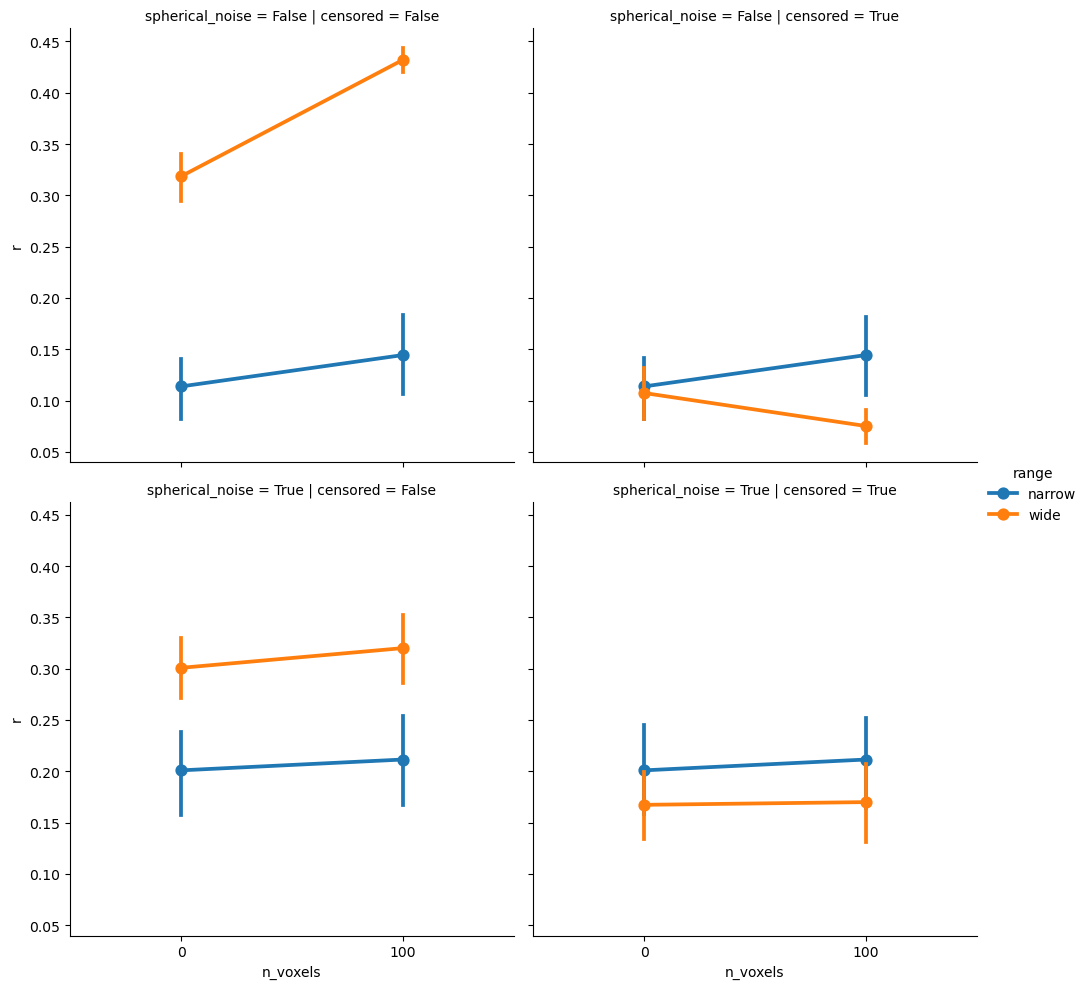

In [6]:
sns.catplot(x='n_voxels', y='r', hue='range', col='censored', row='spherical_noise', data=r_all.reset_index(), kind='point')

<Axes: xlabel='n-range', ylabel='x'>

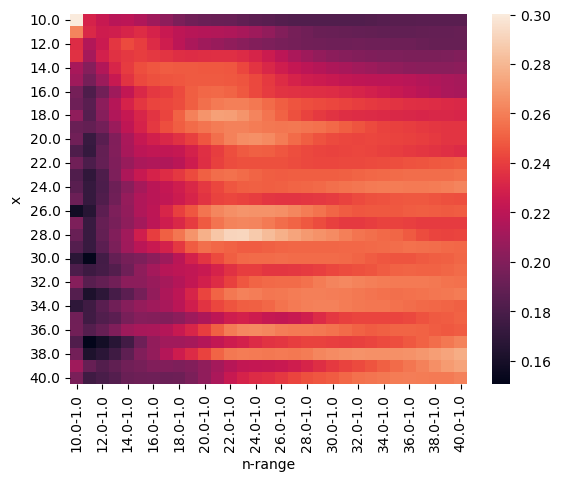

In [7]:
sns.heatmap(pdf.loc[:, (slice(None), '1.0')].groupby('x').mean())

<Axes: xlabel='n-range', ylabel='x'>

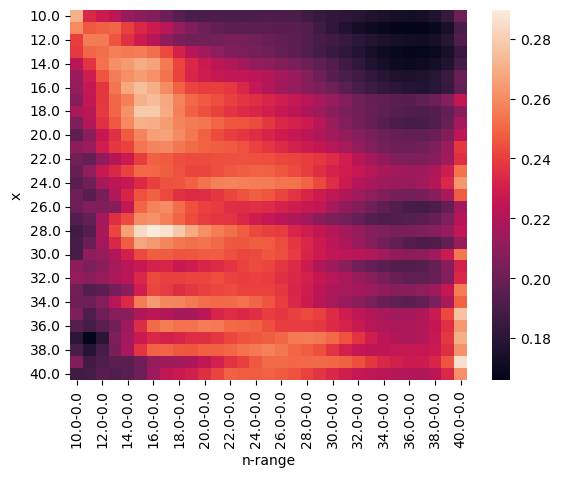

In [8]:
sns.heatmap(pdf.loc[:, (slice(None), '0.0')].groupby('x').mean())

In [9]:
sns.histplot(tmp['E'])

NameError: name 'tmp' is not defined

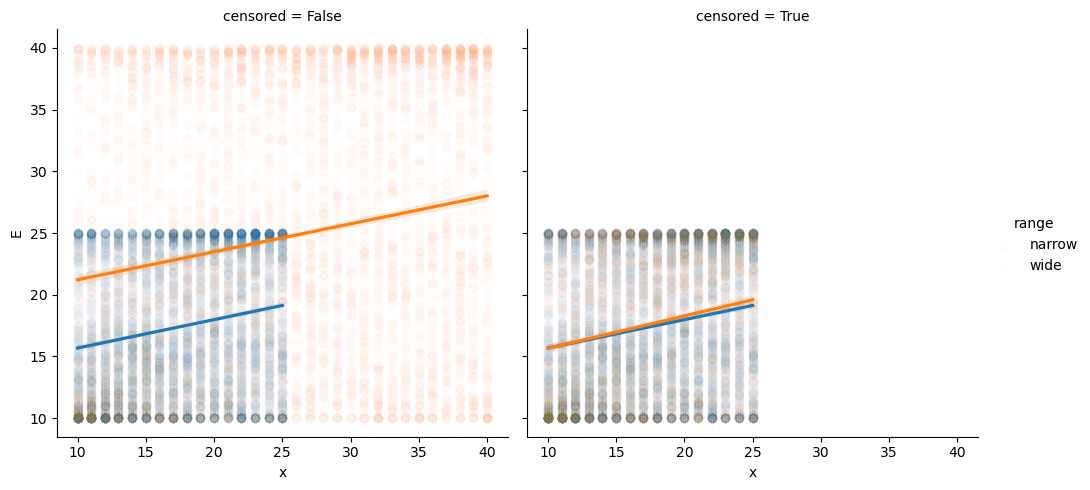

In [ ]:
tmp = pars.xs(True, level='spherical_noise', )


sns.lmplot(x='x', y='E', data=tmp.reset_index(), scatter_kws={'alpha': 0.01}, col='censored', hue='range')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_84435/4034098467.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r = pars.groupby(['subject', 'run', 'session', 'range']).apply(lambda d: pg.corr(d['E'], d['x'], method='pearson')).groupby(['subject', 'range']).mean(numeric_only=True)


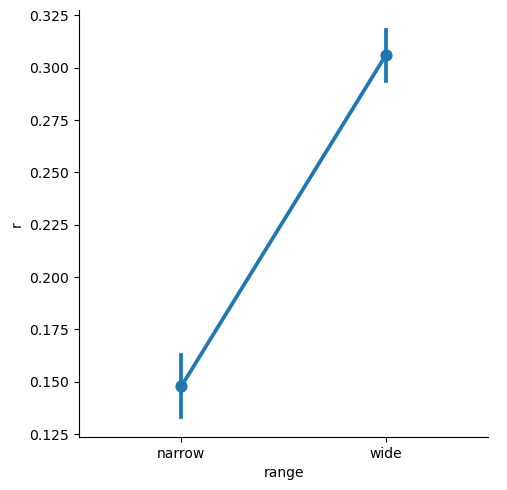

In [97]:
import pingouin as pg
r = pars.groupby(['subject', 'run', 'session', 'range']).apply(lambda d: pg.corr(d['E'], d['x'], method='pearson')).groupby(['subject', 'range']).mean(numeric_only=True)

sns.catplot(data=r.reset_index(), x='range', y='r', kind='point', errorbar='se')

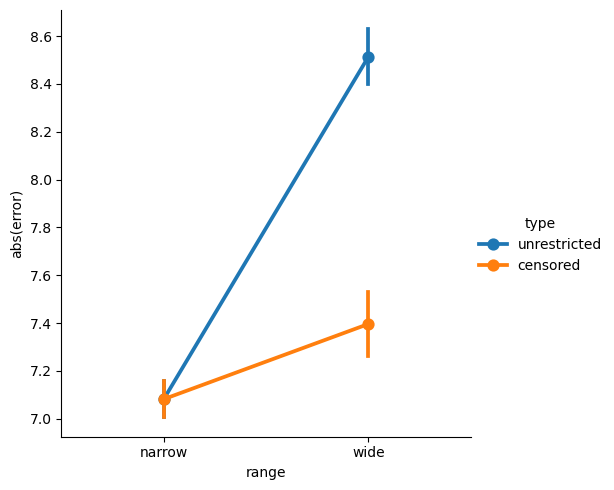

In [10]:
mean_abs_errors_unrestricted = pars.groupby(['subject', 'range']).mean(numeric_only=True).reset_index()
mean_abs_error_censored = pars[pars['x'] < 26].groupby(['subject', 'range']).mean(numeric_only=True).reset_index()
mean_abs_error = pd.concat([mean_abs_errors_unrestricted.assign(type='unrestricted'), mean_abs_error_censored.assign(type='censored')], ignore_index=True)

sns.catplot(x='range', y='abs(error)', hue='type', kind='point', errorbar='se', data=mean_abs_error)

In [98]:
mean_abs_error_censored.groupby(['subject', 'range'])['abs(error)'].mean().groupby('range').agg(['mean', 'std'])

,mean,std
range,,
narrow,7.082209,0.474105
wide,7.396593,0.828707


In [99]:
pg.pairwise_ttests(data=mean_abs_error_censored, dv='abs(error)', within='range', subject='subject')

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,range,narrow,wide,True,True,-2.462632,38.0,two-sided,0.018438,2.452,-0.461071


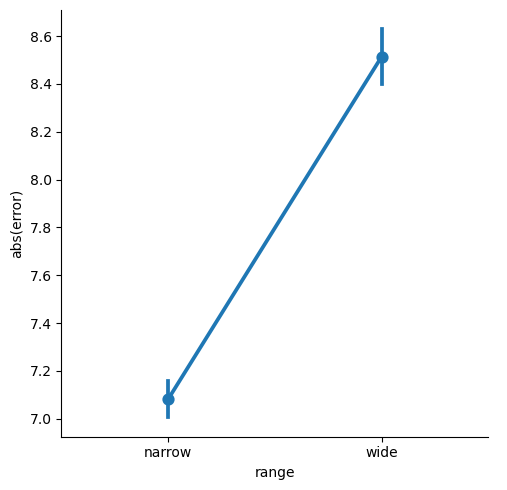

In [11]:
sns.catplot(x='range', y='abs(error)', kind='point', errorbar='se', data=pars.groupby(['subject', 'range']).mean())

In [12]:
pg.ttest(r['r'].unstack('range')['narrow'], r['r'].unstack('range')['wide'], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-2.799177,38,two-sided,0.008006,"[-0.09, -0.01]",0.538018,4.977,0.905561


In [13]:
pg.rm_corr(pars.reset_index(), x='E', y='x', subject='subject')

,r,dof,pval,CI95%,power
rm_corr,0.148171,23478,2.338730e-115,"[0.14, 0.16]",1.0


In [14]:
pars.groupby(['range']).apply(lambda d: pg.rm_corr(d.reset_index(), x='E', y='x', subject='subject'))

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_78349/453097392.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pars.groupby(['range']).apply(lambda d: pg.rm_corr(d.reset_index(), x='E', y='x', subject='subject'))


,,r,dof,pval,CI95%,power
range,,,,,,
narrow,rm_corr,0.100547,11720,1.004131e-27,"[0.08, 0.12]",1.0
wide,rm_corr,0.133463,11718,1.017932e-47,"[0.12, 0.15]",1.0


In [15]:
pars[pars['x'] < 26].groupby(['range']).apply(lambda d: pg.rm_corr(d.reset_index(), x='E', y='x', subject='subject'))

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_78349/1743743966.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pars[pars['x'] < 26].groupby(['range']).apply(lambda d: pg.rm_corr(d.reset_index(), x='E', y='x', subject='subject'))


,,r,dof,pval,CI95%,power
range,,,,,,
narrow,rm_corr,0.100547,11720,1.004131e-27,"[0.08, 0.12]",1.0
wide,rm_corr,0.127652,6072,1.729463e-23,"[0.1, 0.15]",1.0


In [16]:
tmp = pars[pars['x'] < 26].groupby(['subject', 'range']).apply(lambda d: pg.corr(d['E'], d['x'], method='pearson'))

pg.ttest(tmp.unstack('range')['r']['narrow'], tmp.unstack('range')['r']['wide'], paired=True)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_78349/3095372400.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = pars[pars['x'] < 26].groupby(['subject', 'range']).apply(lambda d: pg.corr(d['E'], d['x'], method='pearson'))


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-2.665117,38,two-sided,0.011235,"[-0.09, -0.01]",0.581121,3.726,0.942485


In [17]:
tmp.groupby('range')['r'].mean()

range
narrow    0.081721
wide      0.135697
Name: r, dtype: float64